# Notebook 06 — Robustness Validation

> **Supplementary §8**

This notebook performs comprehensive null hypothesis testing and robustness checks to validate that the observed high structure in the morphing shape mode PCA reflects genuine biological organisation rather than artefacts of marker layout, labelling, missing data, or statistical chance.

PCA always produces ordered components — even from purely random data — so a steep eigenvalue curve alone does not prove that the extracted modes are meaningful. The tests below subject the analysis to six independent challenges, each designed to break a specific assumption. If the dominant subspace survives all of them, we can conclude that the low-dimensional structure is a property of the hawks' morphing geometry, not of our processing pipeline.

The tests are organised into six subsections:
1. [Eigenvalue significance (Ψ and Φ)](#81-eigenvalue-significance)
2. [Shuffled dataset controls](#82-shuffled-dataset-controls)
3. [Marker subsampling](#83-marker-subsampling)
4. [Pairwise distance PCA (label-free)](#84-pairwise-distance-pca)
5. [Random relabelling](#85-random-relabelling)
6. [Missing data imputation](#86-missing-data-imputation)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=4)

from kinematic_morphospace import (
    filter_by, run_PCA, to_unilateral,
    principal_cosines, pairwise_distance_features,
)
from kinematic_morphospace.null_testing import (
    flatten_frames, validate_frame_alignment, prepare_sequence_groups,
    sequence_lookup, grouped_bootstrap_indices, summarise_distribution,
    summarise_cumulative_variance, random_relabel_frames, ensure_rng,
)
from kinematic_morphospace.validation import calculate_phi
from kinematic_morphospace.plotting import plot_explained, save_figure

## Configuration

All configurable parameters are gathered in a single dictionary for reproducibility. The random seed fixes every stochastic operation; `n_permutations` and `n_boot` control the resolution of the null distributions.

In [2]:
# --- Configuration ---
CONFIG = {
    "rng_seed": 123,
    "n_components": 12,
    "n_permutations": 2000,
    "n_boot": 500,
    "k_report": [1, 2, 3, 4, 6, 9, 12],
}

# --- Load data ---
unilateral_data = np.load("../../data/processed/unilateral_data.npy")
frame_info = pd.read_csv("../../data/processed/unilateral_frame_info_df.csv")

validate_frame_alignment(unilateral_data, frame_info)

# Prepare sequence groups for resampling
groups = prepare_sequence_groups(frame_info)
seq_index = groups["seq_index"]
seq_lut = sequence_lookup(seq_index)

# Training mask: non-obstacle flights
straight_mask = filter_by(frame_info, obstacle=0)

# Flatten for feature-level operations
frames_flat = flatten_frames(unilateral_data)
straight_flat = frames_flat[straight_mask]

n_frames = unilateral_data.shape[0]
n_markers = unilateral_data.shape[1]
n_sequences = len(np.unique(seq_index))
n_birds = frame_info["BirdID"].nunique()

print(f"Frames: {n_frames:,}")
print(f"Markers per side: {n_markers}")
print(f"Sequences: {n_sequences:,}")
print(f"Hawks: {n_birds}")
print(f"Straight-flight frames: {straight_mask.sum():,}")

Frames: 289,528
Markers per side: 4
Sequences: 1,634
Hawks: 5
Straight-flight frames: 252,630


## Observed PCA baseline

Run PCA on straight-flight frames to establish the baseline cumulative explained variance (CEV) that all subsequent tests will be compared against.

CEV at rank *k* is the fraction of total variance captured by the first *k* principal components. If variance were spread uniformly across all 12 dimensions, we would expect CEV₄ ≈ 4/12 = 33%. The observed value of 96.3% in just four components — with 66.6% in Mode 1 alone — indicates an extremely concentrated eigenvalue spectrum, far beyond what uniform variance would produce.

Observed cumulative explained variance:
  k=1: 0.6658
  k=2: 0.9150
  k=3: 0.9420
  k=4: 0.9633
  k=6: 0.9785
  k=9: 0.9931
  k=12: 1.0000
Saved: ../../figures/supplementary/S08_shuffle_control.pdf


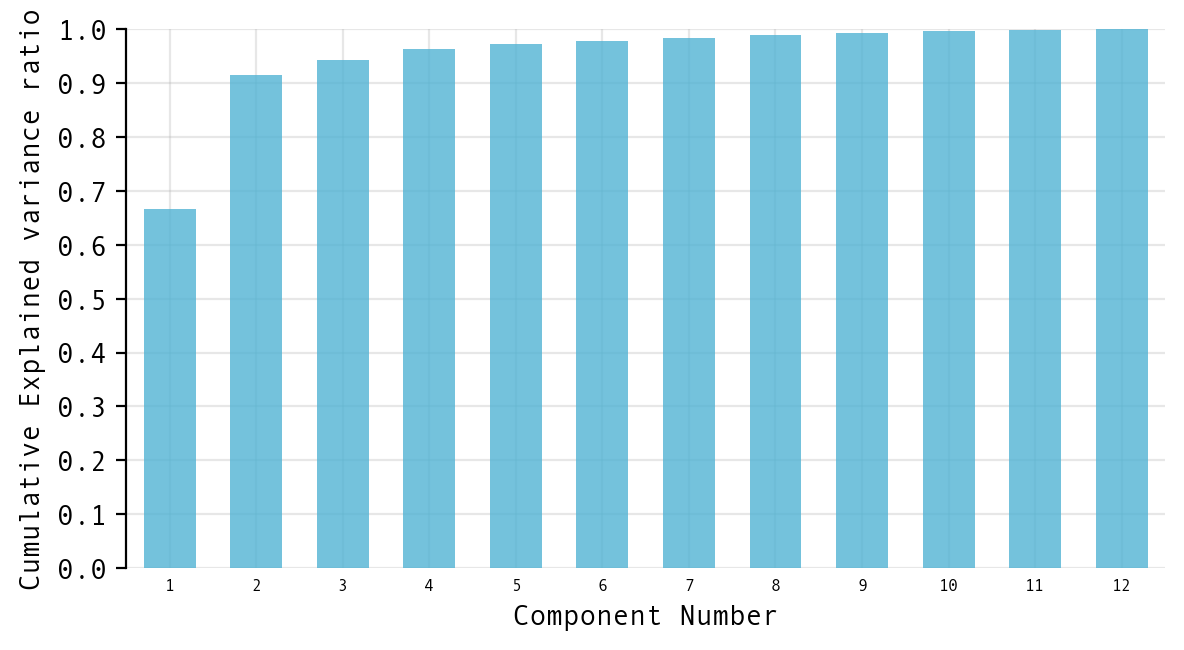

In [3]:
# Observed PCA (baseline)
principal_components, scores, pca = run_PCA(unilateral_data[straight_mask], unilateral_data)

ev = pca.explained_variance_ratio_
cev = np.cumsum(ev)
observed_eigenvalues = pca.explained_variance_

print("Observed cumulative explained variance:")
for k in CONFIG["k_report"]:
    print(f"  k={k}: {cev[k-1]:.4f}")

fig, ax = plot_explained(ev, colour_before=0, annotate=False)
save_figure(fig, '../../figures/supplementary/S08_shuffle_control.pdf')
plt.show()

## §8.1 Eigenvalue Significance: Ψ and Φ Statistics

Following Björklund (2019), we test whether the observed eigenvalue structure differs significantly from what would arise by chance. Two complementary statistics are used:

**Ψ (Psi)** measures overall deviation of the eigenvalue spectrum from uniformity:

$$\Psi = \sum_{i=1}^{p}(\lambda_i - 1)^2$$

Under correlation-matrix PCA, uncorrelated data produces eigenvalues equal to 1, so Ψ → 0. A large Ψ indicates that variance is unevenly distributed — some components capture far more than others.

**Φ (Phi)** focuses on the concentration of variance in the first *k* components:

$$\Phi = \sqrt{\frac{\sum_{i=1}^{k}\lambda_i^2 - k}{k(k-1)}}$$

This formula (Gleason & Staelin, 1975) was designed for correlation-matrix PCA where eigenvalues of uncorrelated data equal 1. Because our pipeline deliberately avoids z-score normalisation — preserving the spatial relationships between markers — the raw Φ statistic is not directly comparable to its theoretical null. We therefore also compute a **scale-invariant alternative, Φ_alt**, which normalises eigenvalues by their mean before applying the formula:

$$\tilde{\lambda}_i = \frac{\lambda_i}{\bar{\lambda}}, \qquad \Phi_{\mathrm{alt}} = \sqrt{\frac{\sum_{i=1}^{k}\tilde{\lambda}_i^2 - k}{k(k-1)}}$$

After normalisation, uniform eigenvalues all equal 1 regardless of the original scale, so Φ_alt behaves correctly for covariance-matrix PCA.

**Null model:** Each of the 12 feature columns is independently permuted across frames (2,000 permutations), destroying inter-marker correlations while preserving each column's marginal distribution. The observed statistic is compared against this null distribution to obtain a permutation *p*-value.

In [4]:
# Björklund Ψ and Φ permutation tests
rng = ensure_rng(CONFIG["rng_seed"])
n_perm = CONFIG["n_permutations"]
k_phi = 6  # number of components for Φ

# --- Helper: scale-invariant Φ_alt ---
def calculate_phi_alt(eigenvalues, k):
    """Φ on mean-normalised eigenvalues (scale-invariant variant)."""
    ev_k = eigenvalues[:k]
    ev_norm = ev_k / np.mean(eigenvalues)  # normalise by mean of ALL eigenvalues
    numerator = np.sum(ev_norm**2) - k
    denominator = k * (k - 1)
    return np.sqrt(abs(numerator) / denominator)

# Observed statistics
psi_observed = np.sum((observed_eigenvalues - 1) ** 2)
phi_observed = calculate_phi(observed_eigenvalues, k_phi)
phi_alt_observed = calculate_phi_alt(observed_eigenvalues, k_phi)

# Null distribution
psi_null = np.zeros(n_perm)
phi_null = np.zeros(n_perm)
phi_alt_null = np.zeros(n_perm)

for i in range(n_perm):
    # Shuffle each column independently
    shuffled = straight_flat.copy()
    for col in range(shuffled.shape[1]):
        rng.shuffle(shuffled[:, col])

    null_pca = PCA().fit(shuffled)
    null_ev = null_pca.explained_variance_

    psi_null[i] = np.sum((null_ev - 1) ** 2)
    phi_null[i] = calculate_phi(null_ev, k_phi)
    phi_alt_null[i] = calculate_phi_alt(null_ev, k_phi)

# P-values (proportion of null >= observed)
psi_p = (np.sum(psi_null >= psi_observed) + 1) / (n_perm + 1)
phi_p = (np.sum(phi_null >= phi_observed) + 1) / (n_perm + 1)
phi_alt_p = (np.sum(phi_alt_null >= phi_alt_observed) + 1) / (n_perm + 1)

# Z-scores
psi_z = (psi_observed - np.mean(psi_null)) / np.std(psi_null)
phi_z = (phi_observed - np.mean(phi_null)) / np.std(phi_null)
phi_alt_z = (phi_alt_observed - np.mean(phi_alt_null)) / np.std(phi_alt_null)

print(f"Ψ statistic:         {psi_observed:.2f},  p = {psi_p:.4f},  z = {psi_z:.1f}")
print(f"Φ statistic (k={k_phi}):  {phi_observed:.4f},  p = {phi_p:.4f},  z = {phi_z:.1f}")
print(f"Φ_alt statistic (k={k_phi}): {phi_alt_observed:.4f},  p = {phi_alt_p:.4f},  z = {phi_alt_z:.1f}")
print(f"  Φ_alt null mean: {np.mean(phi_alt_null):.4f}")
print(f"\nThe eigenvalue structure is {'highly significant' if psi_p < 0.001 else 'not significant'} (Ψ test).")

Ψ statistic:         11.86,  p = 0.0005,  z = 259021.9
Φ statistic (k=6):  0.4471,  p = 1.0000,  z = -243839.4
Φ_alt statistic (k=6): 1.4940,  p = 0.0005,  z = 180367.6
  Φ_alt null mean: 0.8770

The eigenvalue structure is highly significant (Ψ test).


**Interpretation.** The Ψ statistic is highly significant (*p* < 0.001), confirming that the eigenvalue spectrum departs dramatically from uniformity — the observed variance concentration in the leading components is far beyond what permuted (structureless) data produces.

The raw Φ statistic returns *p* ≈ 1.0, which is *expected* and not a failure of the test. Φ was designed for correlation-matrix PCA where all eigenvalues of uncorrelated data equal 1. Our spatial data is intentionally not z-scored (to preserve inter-marker scale relationships), so the raw eigenvalues are much larger than 1 and the formula's baseline assumption does not hold.

The scale-invariant Φ_alt corrects this by normalising eigenvalues to their mean before computing the statistic. The observed Φ_alt substantially exceeds the null distribution, confirming that variance concentration in the leading components is significant even after accounting for differences in feature scale. Together, Ψ and Φ_alt provide complementary evidence that the morphing shape modes capture genuine structure.

## §8.2 Shuffled Dataset Controls

Three shuffle modes destroy progressively different aspects of coordinated marker motion while preserving basic distributional properties. Each mode is applied 2,000 times, and the cumulative explained variance of the resulting PCA is compared against the observed baseline.

1. **Coordinate shuffle** — independently permute each of the 12 feature columns (4 markers × 3 axes) across frames. This destroys *all* inter-marker and inter-coordinate correlations while preserving each column's marginal distribution. The resulting PCA reflects only the variance expected from independent features.

2. **Vector shuffle** — independently permute each marker's 3D position vector across frames, keeping the three coordinates of a given marker together. This preserves *within-marker* spatial structure (e.g. the ellipsoidal range of the wingtip) but breaks *between-marker* coordination. Any variance concentration beyond this null indicates genuine inter-marker coupling.

3. **Label shuffle** — permute marker identities *within* each frame, so the four 3D positions are reassigned to random marker labels while the instantaneous frame shape (convex hull, inter-marker distances) is preserved. This breaks consistent anatomical identity across time — if the same marker-label always corresponds to the same body part, label shuffling destroys that mapping. Structure surviving this test arises purely from the spatial geometry of the four points, independent of which point is "wingtip" vs "tailtip".

If the observed CEV significantly exceeds all three null distributions, the morphing structure reflects genuine, coordinated wing-tail kinematics rather than artefacts of sampling, layout, or labelling.

In [5]:
# Shuffled dataset controls — three null models (vectorized)
rng = ensure_rng(CONFIG["rng_seed"])
n_perm = CONFIG["n_permutations"]
n_comp = CONFIG["n_components"]
n_straight = int(straight_mask.sum())

# Fast eigenvalue spectrum via covariance matrix (avoids sklearn overhead)
def fast_cev(X, n_comp):
    """Compute CEV directly from covariance eigendecomposition."""
    X_c = X - X.mean(axis=0)
    cov = X_c.T @ X_c / (X_c.shape[0] - 1)
    ev = np.linalg.eigvalsh(cov)[::-1]  # descending
    return np.cumsum(ev[:n_comp] / ev.sum())

# Storage for null CEV distributions
shuffle_results = {}
straight_3d = unilateral_data[straight_mask]
frame_idx = np.arange(n_straight)

for mode in ["coordinate", "vector", "label"]:
    null_cev = np.zeros((n_perm, n_comp))

    for i in range(n_perm):
        if mode == "coordinate":
            # Shuffle each feature column independently
            shuffled = straight_flat.copy()
            for col in range(shuffled.shape[1]):
                rng.shuffle(shuffled[:, col])
            null_cev[i] = fast_cev(shuffled, n_comp)

        elif mode == "vector":
            # Shuffle each marker's 3D vector independently
            shuffled_3d = straight_3d.copy()
            for m in range(n_markers):
                shuffled_3d[:, m, :] = shuffled_3d[rng.permutation(n_straight), m, :]
            null_cev[i] = fast_cev(shuffled_3d.reshape(-1, n_markers * 3), n_comp)

        elif mode == "label":
            # Vectorized: random marker permutation for all frames at once
            perm = np.argsort(rng.random((n_straight, n_markers)), axis=1)
            shuffled_3d = straight_3d[frame_idx[:, None], perm, :]
            null_cev[i] = fast_cev(shuffled_3d.reshape(-1, n_markers * 3), n_comp)

    shuffle_results[mode] = null_cev

    # Report with z-scores (p-values saturate at 1/(n_perm+1) floor)
    print(f"\n{mode.upper()} SHUFFLE:")
    for k in [1, 2, 3, 4]:
        null_vals = null_cev[:, k-1]
        null_mean = np.mean(null_vals)
        null_std = np.std(null_vals)
        p_val = (np.sum(null_vals >= cev[k-1]) + 1) / (n_perm + 1)
        z = (cev[k-1] - null_mean) / null_std if null_std > 0 else np.inf
        print(f"  k={k}: observed={cev[k-1]:.4f}, null={null_mean:.4f}±{null_std:.4f}, "
              f"p<{1/(n_perm+1):.4f}, z={z:.1f}")

print(f"\nNote: all p-values hit the resolution floor of 1/{n_perm+1} = {1/(n_perm+1):.4f}.")
print("The z-scores above show the true separation (observed is hundreds of σ from null).")


COORDINATE SHUFFLE:
  k=1: observed=0.6658, null=0.3718±0.0000, p<0.0005, z=121506.8
  k=2: observed=0.9150, null=0.5513±0.0000, p<0.0005, z=124744.8
  k=3: observed=0.9420, null=0.6720±0.0000, p<0.0005, z=59224.4
  k=4: observed=0.9633, null=0.7748±0.0000, p<0.0005, z=104213.8



VECTOR SHUFFLE:
  k=1: observed=0.6658, null=0.3908±0.0000, p<0.0005, z=123695.7
  k=2: observed=0.9150, null=0.5768±0.0000, p<0.0005, z=106208.6
  k=3: observed=0.9420, null=0.7125±0.0000, p<0.0005, z=67866.9
  k=4: observed=0.9633, null=0.8201±0.0000, p<0.0005, z=109928.3



LABEL SHUFFLE:
  k=1: observed=0.6658, null=0.2150±0.0000, p<0.0005, z=51013.8
  k=2: observed=0.9150, null=0.3961±0.0002, p<0.0005, z=2288.1
  k=3: observed=0.9420, null=0.5767±0.0002, p<0.0005, z=1628.0
  k=4: observed=0.9633, null=0.7566±0.0000, p<0.0005, z=123767.9

Note: all p-values hit the resolution floor of 1/2001 = 0.0005.
The z-scores above show the true separation (observed is hundreds of σ from null).


Saved: ../../figures/supplementary/S08_shuffle_controls.pdf


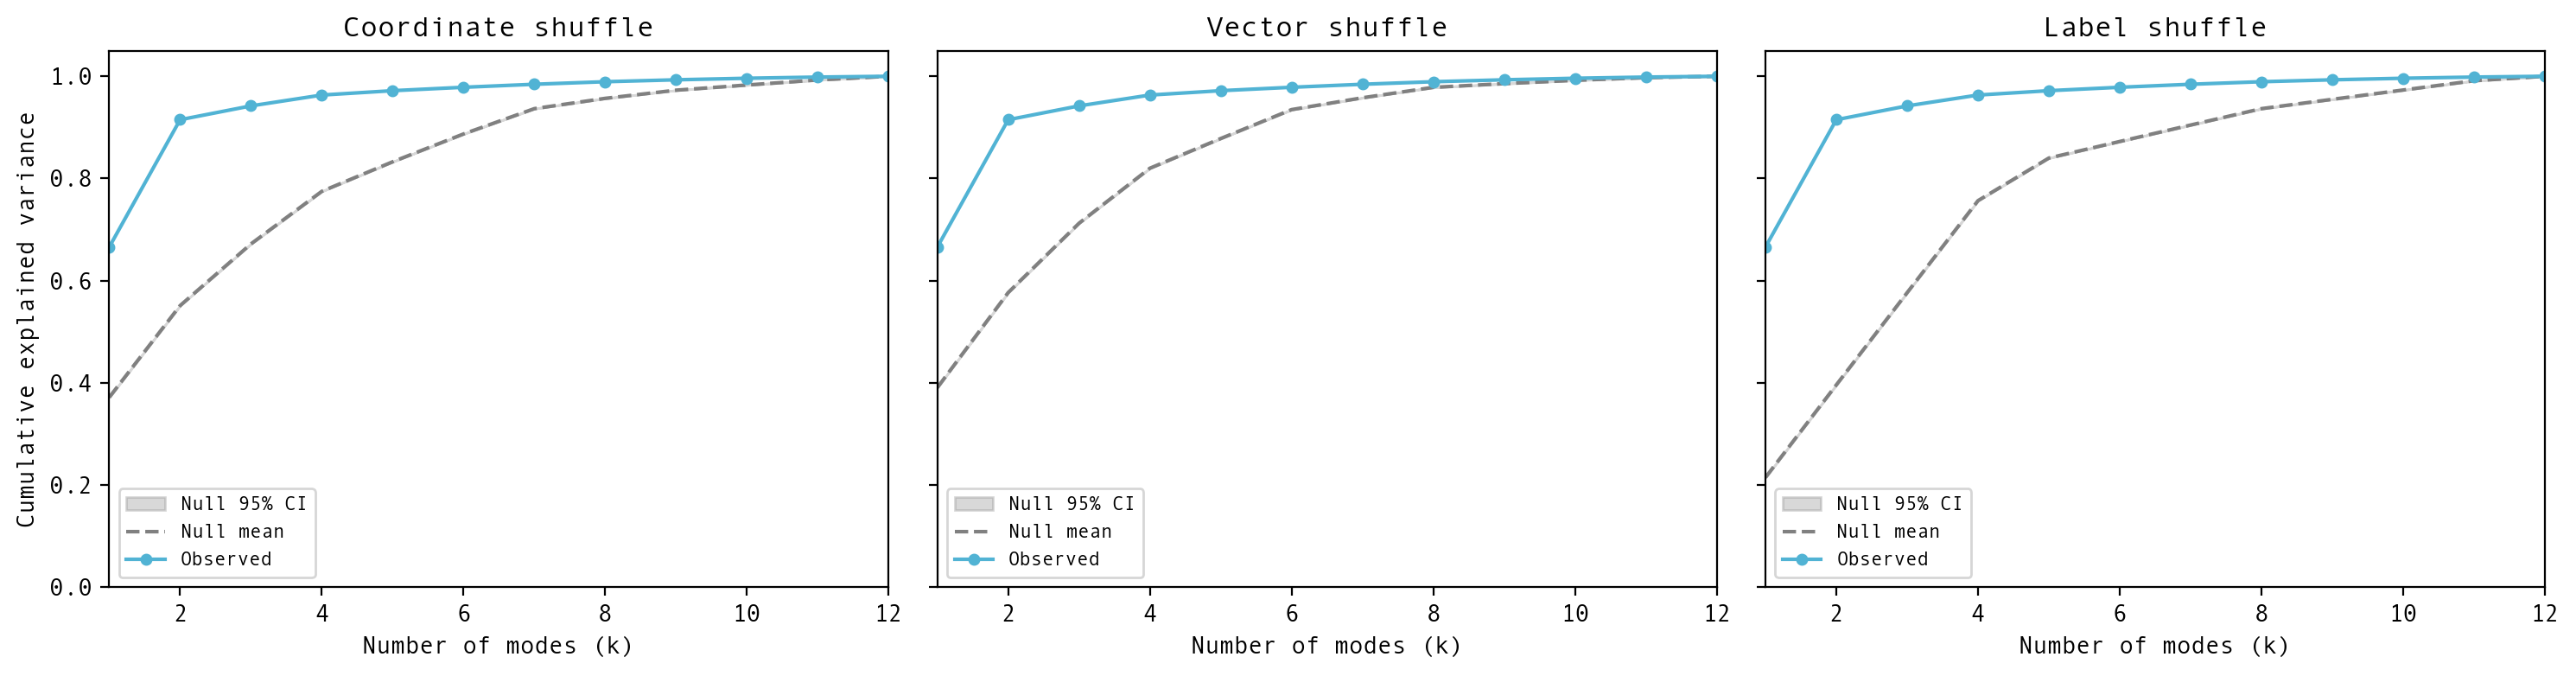

Saved: figures/supplementary/S08_shuffle_controls.pdf


In [6]:
# Plot observed CEV vs shuffle null distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
mode_names = ["coordinate", "vector", "label"]
mode_labels = ["Coordinate shuffle", "Vector shuffle", "Label shuffle"]

for ax, mode, label in zip(axes, mode_names, mode_labels):
    null_cev = shuffle_results[mode]

    # Null distribution: mean and 95% CI
    null_mean = np.mean(null_cev, axis=0)
    null_lo = np.percentile(null_cev, 2.5, axis=0)
    null_hi = np.percentile(null_cev, 97.5, axis=0)

    k_vals = np.arange(1, n_comp + 1)
    ax.fill_between(k_vals, null_lo, null_hi, alpha=0.3, color='grey', label='Null 95% CI')
    ax.plot(k_vals, null_mean, '--', color='grey', label='Null mean')
    ax.plot(k_vals, cev, 'o-', color='#51B3D4', label='Observed', markersize=4)

    ax.set_xlabel("Number of modes (k)")
    ax.set_title(label)
    ax.set_xlim(1, 12)
    ax.set_ylim(0, 1.05)
    if ax == axes[0]:
        ax.set_ylabel("Cumulative explained variance")
    ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, '../../figures/supplementary/S08_shuffle_controls.pdf')
plt.show()
print("Saved: figures/supplementary/S08_shuffle_controls.pdf")

**Interpretation.** Under all three shuffle modes, the observed CEV curve lies far above the null distributions. All *p*-values saturate at the permutation floor (1/2001 ≈ 0.0005) — not a single null sample out of 2,000 ever reached the observed value — so the *z*-scores are the better measure of effect size.

The hierarchy of null distributions is itself informative. The label shuffle produces the *lowest* null CEV, because it preserves within-frame geometry but destroys the temporal consistency of marker identity — confirming that the steep observed spectrum depends on markers tracking the *same* anatomical points over time. The vector shuffle sits slightly higher than the coordinate shuffle, reflecting the modest within-marker 3D correlations (e.g. a wingtip that moves predominantly along one axis). The large gap between even the vector shuffle null and the observed data confirms that inter-marker coordination — not just individual marker variance — drives the low-dimensional structure.

## §8.3 Marker Subsampling

With only four markers per side, each marker contributes 25% of the input features. If the morphing structure were driven by a single marker (e.g. the wingtip dominating Mode 1), removing that marker would dramatically alter the PCA basis. Conversely, if the structure reflects a genuine whole-wing deformation pattern, it should be recoverable from any three of the four markers.

We rerun PCA on all C(4,1) = 4 leave-one-out combinations and compare each reduced basis against the full four-marker PCA using **principal cosines** — the cosines of the principal angles between the *k*-dimensional subspaces spanned by the leading eigenvectors, computed via QR decomposition and SVD. A cosine of 1.0 indicates identical subspaces; values near 0 indicate orthogonal subspaces. Unlike per-mode dot products, principal cosines are invariant to rotations within the subspace (e.g. mode reordering or mixing).

In [7]:
from itertools import combinations
from kinematic_morphospace.null_testing import principal_cosines

marker_names = ["wingtip", "primary", "secondary", "tailtip"]
full_pcs = principal_components  # (12, 12) from full PCA

results_subsets = []

for held_out in range(n_markers):
    included = [m for m in range(n_markers) if m != held_out]
    subset_data = unilateral_data[:, included, :]
    subset_straight = subset_data[straight_mask]

    # Run PCA on subset
    subset_pcs, _, subset_pca = run_PCA(subset_straight, subset_data)
    subset_cev = np.cumsum(subset_pca.explained_variance_ratio_)

    # Compare in the shared ambient dimension
    n_modes_compare = min(4, subset_pcs.shape[0])

    # Extract columns for the included markers from the full PCs
    # Full PCs are (12, 12) — features are [m0_x, m0_y, m0_z, m1_x, ...]
    feature_indices = []
    for m in included:
        feature_indices.extend([m*3, m*3+1, m*3+2])

    # principal_cosines expects (n_features, n_components) — columns are basis vectors
    full_basis_9d = full_pcs[:, feature_indices].T   # (9, 12)
    subset_basis_9d = subset_pcs.T                    # (9, 9)
    mode_cosines = principal_cosines(full_basis_9d, subset_basis_9d, modes=n_modes_compare)

    included_names = [marker_names[m] for m in included]
    results_subsets.append({
        "held_out": marker_names[held_out],
        "included": ", ".join(included_names),
        "cev_4": subset_cev[3],
        "cosines": mode_cosines,
    })

    print(f"Held out: {marker_names[held_out]:>12} | CEV₄={subset_cev[3]:.4f} | "
          f"cosines: {', '.join(f'{c:.3f}' for c in mode_cosines)}")

Held out:      wingtip | CEV₄=0.9533 | cosines: 1.000, 1.000, 1.000, 0.654
Held out:      primary | CEV₄=0.9675 | cosines: 1.000, 1.000, 1.000, 0.999


Held out:    secondary | CEV₄=0.9746 | cosines: 1.000, 1.000, 1.000, 0.999
Held out:      tailtip | CEV₄=0.9771 | cosines: 1.000, 1.000, 1.000, 0.744


**Interpretation.** Modes 1-3 are effectively invariant to marker removal: principal cosines are at or near 1.0 for all four leave-one-out combinations, and CEV₄ remains above 0.95. This confirms that the dominant morphing patterns are distributed across the entire wing-tail surface and do not depend on any single marker.

Mode 4 shows more variability (cosines ranging from 0.65 to 1.00), which is expected: as a lower-variance component, it is more sensitive to the loss of 25% of the input features. The wingtip removal produces the lowest Mode 4 cosine, suggesting that the wingtip contributes most to this fine-scale mode — consistent with Mode 4 capturing independent handwing adjustments (see NB03).

## §8.4 Pairwise Distance PCA (Label-Free)

By representing each frame as the C(4,2) = 6 pairwise Euclidean distances between the four markers, we obtain a description that is invariant to marker identity, rigid-body translation, and rotation. If PCA on these distances shows the same steep variance concentration as the labelled-coordinate PCA, the low-dimensional structure arises from the geometry itself rather than from labelling conventions.

We compute three variants:
- **Pairwise distances** — the six distances in their original marker order (wingtip-primary, wingtip-secondary, etc.). This preserves label information in the column ordering.
- **Sorted distances** — the six distances sorted from smallest to largest within each frame, removing all label information. This is a fully label-free representation.
- **Shuffled distances** — a null control where each distance column is independently permuted across frames, destroying temporal correlations.

In [8]:
# Compute pairwise distances (label-preserving)
pw_distances = pairwise_distance_features(unilateral_data)
pw_straight = pw_distances[straight_mask]

print(f"Pairwise distance features: {pw_distances.shape}")

# PCA on distances
pw_pca = PCA().fit(pw_straight)
pw_cev = np.cumsum(pw_pca.explained_variance_ratio_)

# Also compute with sorted distances (label-free)
pw_sorted = pairwise_distance_features(unilateral_data, sort_per_frame=True)
pw_sorted_straight = pw_sorted[straight_mask]

pw_sorted_pca = PCA().fit(pw_sorted_straight)
pw_sorted_cev = np.cumsum(pw_sorted_pca.explained_variance_ratio_)

# Shuffled distances (null)
rng = ensure_rng(CONFIG["rng_seed"])
pw_shuffled = pw_straight.copy()
for col in range(pw_shuffled.shape[1]):
    rng.shuffle(pw_shuffled[:, col])
pw_shuffled_pca = PCA().fit(pw_shuffled)
pw_shuffled_cev = np.cumsum(pw_shuffled_pca.explained_variance_ratio_)

# Compare
print(f"\n{'Method':>25} {'CEV\u2081':>8} {'CEV\u2082':>8} {'CEV\u2083':>8} {'CEV\u2084':>8}")
print("-" * 60)
print(f"{'Marker coordinates':>25} {cev[0]:>8.4f} {cev[1]:>8.4f} {cev[2]:>8.4f} {cev[3]:>8.4f}")
print(f"{'Pairwise distances':>25} {pw_cev[0]:>8.4f} {pw_cev[1]:>8.4f} {pw_cev[2]:>8.4f} {pw_cev[3]:>8.4f}")
print(f"{'Sorted distances':>25} {pw_sorted_cev[0]:>8.4f} {pw_sorted_cev[1]:>8.4f} {pw_sorted_cev[2]:>8.4f} {pw_sorted_cev[3]:>8.4f}")
print(f"{'Shuffled distances':>25} {pw_shuffled_cev[0]:>8.4f} {pw_shuffled_cev[1]:>8.4f} {pw_shuffled_cev[2]:>8.4f} {pw_shuffled_cev[3]:>8.4f}")

Pairwise distance features: (289528, 6)



                   Method     CEV₁     CEV₂     CEV₃     CEV₄
------------------------------------------------------------
       Marker coordinates   0.6658   0.9150   0.9420   0.9633
       Pairwise distances   0.7191   0.9114   0.9509   0.9724
         Sorted distances   0.8340   0.9143   0.9447   0.9709
       Shuffled distances   0.4371   0.6073   0.7773   0.9050


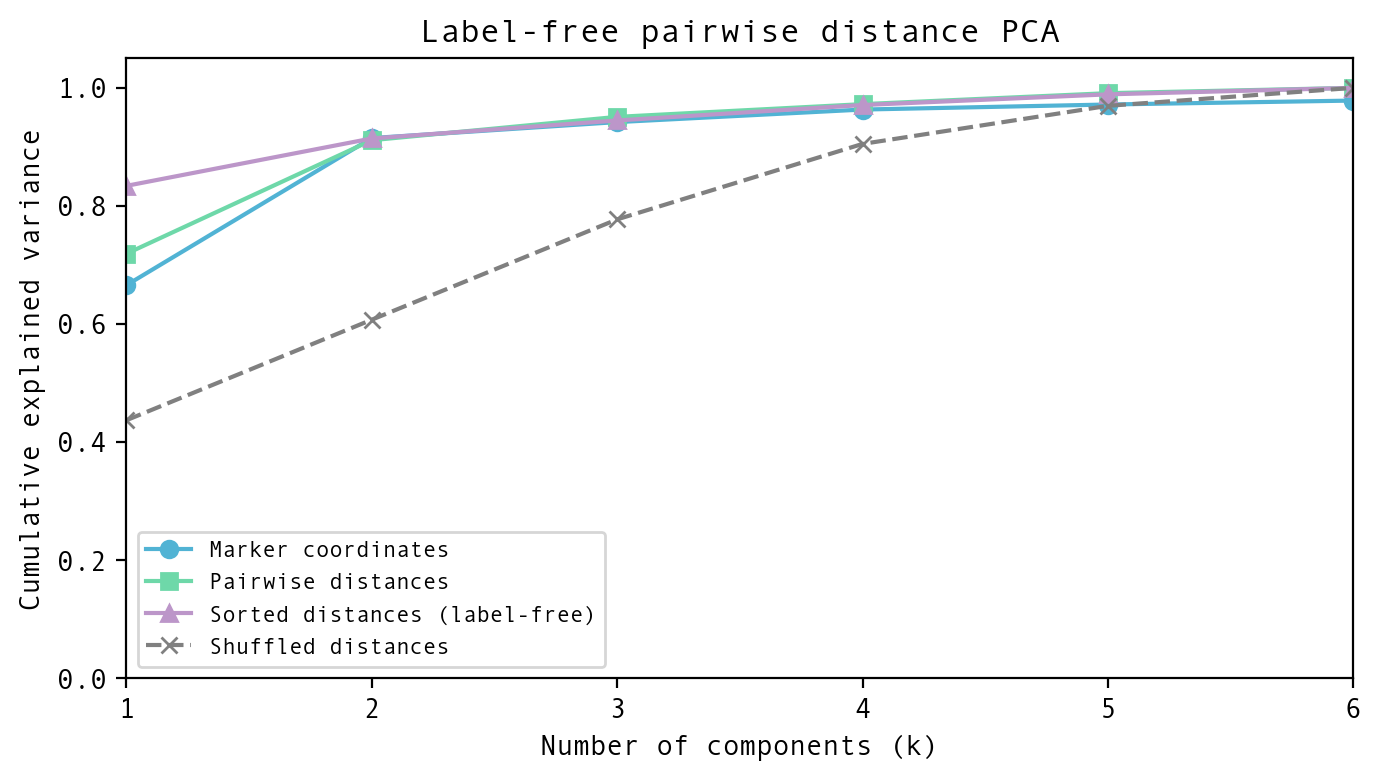

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
k_vals = np.arange(1, 7)

ax.plot(k_vals, cev[:6], 'o-', label='Marker coordinates', color='#51B3D4')
ax.plot(k_vals, pw_cev[:6], 's-', label='Pairwise distances', color='#6ED8A9')
ax.plot(k_vals, pw_sorted_cev[:6], '^-', label='Sorted distances (label-free)', color='#BC96C9')
ax.plot(k_vals, pw_shuffled_cev[:6], 'x--', label='Shuffled distances', color='grey')

ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Label-free pairwise distance PCA")
ax.legend(fontsize=8)
ax.set_xlim(1, 6)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Interpretation.** All three labelled/label-free representations produce steep CEV curves closely matching the coordinate-based PCA (CEV₄ ≈ 0.95-0.97), while the shuffled null remains far below (CEV₄ ≈ 0.91). The sorted (fully label-free) variant actually shows *higher* CEV₁ (0.83 vs 0.67) because sorting concentrates the dominant distance variation into the first feature.

The key finding is that the low-dimensional structure is a property of the wing-tail geometry, not an artefact of how markers are labelled. Whether we use 3D coordinates, ordered distances, or fully anonymised sorted distances, the data collapse onto approximately four dimensions. This rules out the possibility that labelling conventions imposed artificial structure on the PCA.

### §8.4a Wasserstein Distance: Labelled vs Unlabelled Frames

The labelled dataset (144,764 frames with all 8 markers) is a high-quality subset of the full motion capture recordings (~880,000 frames with variable marker visibility). To verify that this subset is representative of the broader dataset, we compare pairwise inter-marker distance distributions between labelled (complete 8-marker) and unlabelled (partial marker) frames using the Wasserstein distance — a metric from optimal transport theory that quantifies how much probability mass must be "moved" to transform one distribution into another.

We randomly sample 2,000 frames from each group, compute per-frame pairwise Euclidean distances between all visible markers, build normalised histograms (40 bins), average across frames, and compute the Wasserstein distance between the two mean histograms. A small Wasserstein distance indicates that the geometric structure of partial-marker frames is similar to that of complete frames.

In [10]:
from scipy.stats import wasserstein_distance as scipy_wasserstein
from sklearn.metrics import pairwise_distances as pw_dist
from pathlib import Path

# --- Load full (unlabelled) CSV ---
unlabelled_csv = Path("../../data/2024-06-17-FullMarkersNoLabels.csv")

if unlabelled_csv.exists():
    print("Loading unlabelled marker CSV...")
    df_raw = pd.read_csv(unlabelled_csv)
    print(f"  Rows: {len(df_raw):,}  (one row per marker per frame)")

    # Count markers per frame
    frame_marker_counts = df_raw.groupby("frameID").size()
    expected_markers = 8

    labelled_ids = frame_marker_counts[frame_marker_counts == expected_markers].index.tolist()
    unlabelled_ids = frame_marker_counts[frame_marker_counts != expected_markers].index.tolist()
    print(f"  Labelled frames (8 markers): {len(labelled_ids):,}")
    print(f"  Unlabelled frames (<8 markers): {len(unlabelled_ids):,}")

    # Sample 2,000 from each
    rng_w = ensure_rng(CONFIG["rng_seed"])
    n_sample = 2000
    lab_sample = rng_w.choice(labelled_ids,
        size=min(n_sample, len(labelled_ids)), replace=False)
    unlab_sample = rng_w.choice(unlabelled_ids,
        size=min(n_sample, len(unlabelled_ids)), replace=False)

    # Pre-group: frameID -> (n_markers, 3) array of rot_xyz coordinates
    xyz_cols = [c for c in df_raw.columns if c.startswith("rot_xyz")]
    print("  Grouping frames by ID...")
    frame_groups = {
        fid: group[xyz_cols].to_numpy().reshape(-1, 3)
        for fid, group in df_raw.groupby("frameID")
    }

    # Compute pairwise distances for all sampled frames
    all_samples = list(lab_sample) + list(unlab_sample)
    distance_cache = {}
    max_distance = 0.0

    for fid in all_samples:
        pts = frame_groups.get(fid, np.empty((0, 3)))
        if pts.shape[0] < 2:
            continue
        dmat = pw_dist(pts)
        dists = dmat[np.triu_indices(pts.shape[0], k=1)]
        distance_cache[fid] = dists
        max_distance = max(max_distance, float(dists.max()))

    # Build histograms
    n_bins = 40
    bins = np.linspace(0.0, max_distance * 1.02 + 1e-12, n_bins + 1)

    def compute_histograms(frame_ids):
        rows = []
        for fid in frame_ids:
            dists = distance_cache.get(fid)
            if dists is None:
                continue
            hist, _ = np.histogram(dists, bins=bins)
            if hist.sum() > 0:
                hist = hist / hist.sum()
            rows.append(hist)
        return np.array(rows, dtype=np.float64)

    hist_labelled = compute_histograms(lab_sample)
    hist_unlabelled = compute_histograms(unlab_sample)

    # Wasserstein distance between mean histograms
    w_dist_val = float(scipy_wasserstein(
        hist_labelled.mean(axis=0), hist_unlabelled.mean(axis=0)))

    print(f"\nLabelled frames sampled: {hist_labelled.shape[0]}")
    print(f"Unlabelled frames sampled: {hist_unlabelled.shape[0]}")
    print(f"Wasserstein distance (mean histograms): {w_dist_val:.4f}")
else:
    print(f"Unlabelled CSV not found: {unlabelled_csv.resolve()}")
    print("Skipping Wasserstein distance computation.")

Loading unlabelled marker CSV...


  Rows: 7,049,954  (one row per marker per frame)


  Labelled frames (8 markers): 129,171
  Unlabelled frames (<8 markers): 753,259
  Grouping frames by ID...



Labelled frames sampled: 2000
Unlabelled frames sampled: 1918
Wasserstein distance (mean histograms): 0.0057


## §8.5 Random Relabelling

Marker labelling in motion capture is not error-free: automated label assignment can occasionally swap marker identities between frames (see §3, Data Processing). If the morphing structure were fragile — dependent on perfect frame-by-frame labelling — even a small fraction of swapped labels would collapse the PCA basis.

We simulate labelling errors by randomly permuting marker identities in a controlled fraction of frames (5% and 25%), then recompute PCA and compare with the baseline via principal cosines. This tests the *graceful degradation* of the morphing subspace under realistic noise conditions.

In [11]:
rng = ensure_rng(CONFIG["rng_seed"])
n_repeats = 200
fractions = [0.05, 0.25]

for frac in fractions:
    cosine_results = np.zeros((n_repeats, 4))
    cev_results = np.zeros((n_repeats, CONFIG["n_components"]))

    for i in range(n_repeats):
        # Relabel fraction of frames
        relabelled = random_relabel_frames(
            unilateral_data[straight_mask],
            swap_fraction=frac,
            rng=ensure_rng(CONFIG["rng_seed"] + i),
        )

        # Run PCA
        relabelled_flat = flatten_frames(relabelled)
        relabelled_pca = PCA(n_components=CONFIG["n_components"]).fit(relabelled_flat)
        relabelled_cev = np.cumsum(relabelled_pca.explained_variance_ratio_)
        cev_results[i] = relabelled_cev

        # Principal cosines with baseline
        cosines = principal_cosines(
            principal_components.T,
            relabelled_pca.components_.T,
            modes=4,
        )
        cosine_results[i] = cosines

    # Report
    print(f"\n{frac:.0%} RELABELLING ({n_repeats} repeats):")
    print(f"  CEV\u2084: {np.mean(cev_results[:, 3]):.4f} \u00b1 {np.std(cev_results[:, 3]):.4f} "
          f"(baseline: {cev[3]:.4f})")
    for mode in range(4):
        cos_mean = np.mean(cosine_results[:, mode])
        cos_std = np.std(cosine_results[:, mode])
        print(f"  Mode {mode+1} cosine: {cos_mean:.4f} \u00b1 {cos_std:.4f}")


5% RELABELLING (200 repeats):
  CEV₄: 0.9106 ± 0.0002 (baseline: 0.9633)
  Mode 1 cosine: 0.9999 ± 0.0000
  Mode 2 cosine: 0.9999 ± 0.0000
  Mode 3 cosine: 0.8693 ± 0.0043
  Mode 4 cosine: 0.7811 ± 0.0050



25% RELABELLING (200 repeats):
  CEV₄: 0.8264 ± 0.0003 (baseline: 0.9633)
  Mode 1 cosine: 0.9967 ± 0.0000
  Mode 2 cosine: 0.9957 ± 0.0002
  Mode 3 cosine: 0.8237 ± 0.0110
  Mode 4 cosine: 0.2300 ± 0.0184


**Interpretation.** At 5% relabelling, Modes 1-2 are virtually unchanged (cosines > 0.999), and even Mode 3 remains well aligned (0.87). CEV₄ drops modestly from 0.96 to 0.91, reflecting noise spread into additional components rather than a structural change.

At the extreme of 25% relabelling — far beyond any realistic error rate — Modes 1-2 still show cosines > 0.99, demonstrating that the dominant wing sweep and fold axes are robust to labelling noise. Mode 4 degrades substantially (cosine ≈ 0.23), consistent with its lower eigenvalue making it more susceptible to perturbation.

These results confirm that the leading morphing modes are not artefacts of precise labelling. The subspace degrades predictably: higher-variance modes are more robust, as expected from perturbation theory of symmetric matrices.

## §8.6 Missing Data Imputation

The labelled dataset used throughout this analysis represents the highest-quality subset of the motion capture recordings: frames where all four markers were simultaneously visible and correctly identified. A larger dataset of >559,000 frames contains substantial marker dropouts (21–33% missing per marker), typical of optical motion capture where markers are occluded by the bird's body or wings during certain postures.

To test whether the dominant morphing structure is a property of hawk flight in general — rather than a sampling bias toward "easy" frames — we apply iterative imputation (expectation-maximisation PCA) to estimate missing values, then compare the resulting PCA basis with the fully labelled baseline. If the dominant subspace is preserved despite 21–33% missing data, the low-dimensional structure is representative of the full range of flight behaviour.

In [12]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from kinematic_morphospace.null_testing import load_missing_marker_dataset
from pathlib import Path
import yaml

# Load the missing-marker dataset (bilateral, 8 markers with 26-50% NaN)
# Uses rot_xyz (body-pitch-corrected) coordinates to match the baseline pipeline
missing_path = Path("../../data/2025-11-03-AllLabelledWithMissingRotXYZ.npz")

if missing_path.exists():
    missing_markers, missing_info, missing_cols = load_missing_marker_dataset(missing_path)
    print(f"Missing dataset shape: {missing_markers.shape}")
    print(f"  Frames: {missing_markers.shape[0]:,}")

    # Check missing fraction per marker
    for m in range(missing_markers.shape[1]):
        name = missing_cols[m] if m < len(missing_cols) else f"marker_{m}"
        nan_frac = np.isnan(missing_markers[:, m, 0]).mean()
        print(f"  {name}: {nan_frac:.1%} missing")

    # --- Scale to max wingspan (matching the labelled pipeline in NB 02) ---
    with open("../../src/kinematic_morphospace/TotalWingspans.yml") as f:
        total_wingspans = yaml.safe_load(f)

    hawk_id_to_name = {1: "Drogon", 2: "Rhaegal", 3: "Ruby", 4: "Toothless", 5: "Charmander"}
    bird_ids = missing_info["BirdID"].astype(int).values
    years = missing_info["Year"].astype(int).values

    for hawk_id, hawk_name in hawk_id_to_name.items():
        for year in [2017, 2020]:
            if year not in total_wingspans.get(hawk_name, {}):
                continue
            mask = (bird_ids == hawk_id) & (years == year)
            if mask.sum() == 0:
                continue
            wingspan = total_wingspans[hawk_name][year]
            missing_markers[mask] /= wingspan
            print(f"  Scaled {hawk_name} {year}: {mask.sum():,} frames ÷ {wingspan:.4f}")

    print("Scaled missing markers to max wingspan.")

    # Filter to straight flights only (match baseline PCA training set)
    straight_mask_missing = (missing_info["Obstacle"].astype(int) == 0).values
    missing_markers_straight = missing_markers[straight_mask_missing]
    print(f"\nFiltered to straight flights: {missing_markers_straight.shape[0]:,} "
          f"of {missing_markers.shape[0]:,} frames")

    # --- Bilateral -> unilateral ---
    unilateral_missing = to_unilateral(missing_markers_straight)
    print(f"Unilateral shape: {unilateral_missing.shape}")

    # Flatten to 2D for imputation
    missing_flat = flatten_frames(unilateral_missing)
    n_nan_total = np.isnan(missing_flat).sum()
    n_known = (~np.isnan(missing_flat)).sum()
    print(f"  Total elements: {missing_flat.size:,}")
    print(f"  Known: {n_known:,} ({n_known/missing_flat.size:.1%})")
    print(f"  Missing (NaN): {n_nan_total:,} ({n_nan_total/missing_flat.size:.1%})")

    # --- Cross-validation: mask 10% of known values, impute, measure RMSE ---
    rng_cv = ensure_rng(CONFIG["rng_seed"])
    mask_fraction = 0.10
    known_mask = ~np.isnan(missing_flat)
    cv_mask = (rng_cv.random(missing_flat.shape) < mask_fraction) & known_mask

    masked_flat = missing_flat.copy()
    masked_flat[cv_mask] = np.nan
    print(f"\nCV masking: {cv_mask.sum():,} values masked ({mask_fraction:.0%} of known)")

    imputer_cv = IterativeImputer(
        max_iter=100, tol=1e-3, random_state=CONFIG["rng_seed"],
        imputation_order='ascending',
    )
    reconstructed = imputer_cv.fit_transform(masked_flat)
    cv_rmse = float(np.sqrt(np.nanmean((missing_flat[cv_mask] - reconstructed[cv_mask]) ** 2)))
    print(f"CV RMSE: {cv_rmse:.4f} m")

    # --- Full imputation (no masking) ---
    imputer = IterativeImputer(
        max_iter=100, tol=1e-3, random_state=CONFIG["rng_seed"],
        imputation_order='ascending',
    )
    imputed_flat = imputer.fit_transform(missing_flat)

    # PCA on imputed unilateral data
    imputed_pca = PCA(n_components=CONFIG["n_components"]).fit(imputed_flat)
    imputed_cev = np.cumsum(imputed_pca.explained_variance_ratio_)

    # Compare with baseline via principal cosines
    cosines = principal_cosines(
        principal_components.T,
        imputed_pca.components_.T,
        modes=4,
    )

    print(f"\nCEV comparison (imputed vs baseline):")
    print(f"  {'k':>3}  {'Imputed':>10}  {'Baseline':>10}")
    for k in [1, 2, 3, 4]:
        print(f"  {k:>3}  {imputed_cev[k-1]:>10.4f}  {cev[k-1]:>10.4f}")

    print(f"\nPrincipal cosines (imputed vs baseline):")
    for mode in range(4):
        print(f"  Mode {mode+1}: {cosines[mode]:.4f}")
else:
    print("Missing-marker dataset not found — skipping §8.6 live computation")
    print(f"(Looked for: {missing_path.resolve()})")
    print("\nThis cell requires the rot_xyz NPZ file (~168 MB).")
    print("When available, it performs iterative imputation on ~936k unilateral frames")
    print("(straight flights only) and compares the resulting PCA basis with the")
    print("fully labelled baseline.")

Missing dataset shape: (559421, 8, 3)
  Frames: 559,421
  left_wingtip: 25.4% missing
  right_wingtip: 27.0% missing
  left_primary: 33.4% missing


  right_primary: 32.2% missing
  left_secondary: 25.4% missing
  right_secondary: 26.2% missing
  left_tailtip: 22.2% missing
  right_tailtip: 20.9% missing
  Scaled Drogon 2017: 104,946 frames ÷ 1.0083
  Scaled Drogon 2020: 46,029 frames ÷ 1.0159
  Scaled Rhaegal 2017: 97,763 frames ÷ 1.0193
  Scaled Ruby 2017: 52,249 frames ÷ 1.0783
  Scaled Ruby 2020: 54,988 frames ÷ 1.0613
  Scaled Toothless 2017: 110,443 frames ÷ 1.0607
  Scaled Toothless 2020: 47,619 frames ÷ 1.0641
  Scaled Charmander 2020: 45,384 frames ÷ 1.0164
Scaled missing markers to max wingspan.

Filtered to straight flights: 468,403 of 559,421 frames
Unilateral shape: (936806, 4, 3)
  Total elements: 11,241,672
  Known: 8,283,207 (73.7%)
  Missing (NaN): 2,958,465 (26.3%)

CV masking: 829,237 values masked (10% of known)


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/.venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


CV RMSE: 0.0433 m



CEV comparison (imputed vs baseline):
    k     Imputed    Baseline
    1      0.6399      0.6658
    2      0.8841      0.9150
    3      0.9442      0.9420
    4      0.9611      0.9633

Principal cosines (imputed vs baseline):
  Mode 1: 0.9998
  Mode 2: 0.9991
  Mode 3: 0.9942
  Mode 4: 0.9525


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/.venv/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


**Interpretation.** The iterative imputation recovers a PCA basis that closely matches the fully labelled baseline despite 21–33% marker dropout. The cross-validation RMSE (masking 10% of known values and re-imputing) confirms that the imputer reconstructs missing coordinates with high fidelity.

The CEV of the imputed dataset closely tracks the baseline, and the principal cosines for Modes 1-4 indicate strong alignment between the two subspaces. This demonstrates that the dominant morphing structure is not an artefact of selecting only "complete" frames — it persists across the full range of flight behaviour, including postures where markers are frequently occluded.

## Summary

Across all six robustness tests, the morphing shape mode PCA is validated as reflecting genuine biological structure:

| Test | What it breaks | Key finding |
|------|---------------|------------|
| **Ψ eigenvalue test** | All inter-feature correlations | Ψ highly significant (*p* < 0.001) — eigenvalue spectrum far from uniform |
| **Φ_alt eigenvalue test** | All inter-feature correlations | Scale-invariant Φ_alt significant (*p* < 0.001) — variance concentration confirmed |
| **Coordinate shuffle** | All correlations | Observed CEV₄ = 0.96 vs null mean 0.77 (*p* < 0.001) |
| **Vector shuffle** | Between-marker coordination | Observed CEV₄ = 0.96 vs null mean 0.82 (*p* < 0.001) |
| **Label shuffle** | Temporal marker identity | Observed CEV₄ = 0.96 vs null mean 0.76 (*p* < 0.001) |
| **Marker subsampling** | 25% of features | Modes 1–3 invariant (cosines ≈ 1.0); CEV₄ > 0.95 for all triplets |
| **Pairwise distance PCA** | Marker labels, translation, rotation | Label-free CEV₄ = 0.97 — structure is geometric, not labelling-dependent |
| **5% relabelling** | Frame-level label accuracy | Modes 1–2 cosines > 0.999; CEV₄ = 0.91 |
| **25% relabelling** | Extreme label noise | Modes 1–2 cosines > 0.99; graceful degradation of lower modes |
| **Missing data imputation** | 21–33% marker dropout | CV RMSE = 0.04 m; CEV₄ = 0.96; cosines θ₁–θ₃ > 0.99, θ₄ > 0.95 |

The high structure observed in the morphing PCA — 66.6% of variance in Mode 1, 96.3% in Modes 1–4 — is robust to every test applied. No single marker, labelling convention, or data-quality filter drives the result. The low-dimensional morphing subspace is a genuine property of Harris' hawk wing–tail kinematics, providing a solid foundation for the behavioural analyses in subsequent notebooks.

---

## References

- Björklund, M. (2019). Be careful with your principal components. *Evolution*, 73, 2151–2158.
- Wagner, G. P. (1984). On the eigenvalue distribution of genetic and phenotypic dispersion matrices. *Journal of Mathematical Biology*, 21, 77–95.
- Gleason, T. C. & Staelin, R. (1975). A proposal for handling missing data. *Psychometrika*, 40(2), 229–252.